In [1]:
# Imports and dataset loading
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name + ".pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=150, bbox_inches="tight")

# Training set overview
df = pd.read_csv("data/training_set_VU_DM.csv")
df.head(5)

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,1,2.83,0.0438,4.95,27,104.77,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,1,2.20,0.0149,5.03,26,170.74,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,1,2.20,0.0245,4.92,21,179.80,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,1,2.83,0.0125,4.39,34,602.77,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,-1.0,0.0,5.0,-1.0,0.0,5.0,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,1,2.64,0.1241,4.93,4,143.58,0,23246,1,0,4,0,1,1,NaN,NaN,1,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [2]:
# Basic Data Exploration

# Training set size
training_set_size = len(df)
print("Training set size (number of rows):", training_set_size)

# Unique searches
unique_searches = df['srch_id'].nunique()
print("Number of unique searches (srch_id):", unique_searches)

# Unique hotels 
unique_hotels = df['prop_id'].nunique()
print("Number of unique hotels (prop_id):", unique_hotels, ", of which")

# Number of major chain hotels
major_chain_hotels = df[df['prop_brand_bool'] == 1]['prop_id'].nunique()
independent_hotels = df[df['prop_brand_bool'] == 0]['prop_id'].nunique()
print("     -", major_chain_hotels, "belong to a major chain")
print("     -", independent_hotels, "are independent hotels")

#Unique countries where hotels are located
unique_countries_hotel = df['prop_country_id'].nunique()
print("Number of unique countries where hotels are located (prop_country_id):", unique_countries_hotel)

#Unique countries where customers are located
unique_countries_customers = df['visitor_location_country_id'].nunique()
print("Number of unique countries where customers are located (visitor_location_country_id):", unique_countries_customers)

# Duration of sampling period
df['date_time'] = pd.to_datetime(df['date_time'])
first_day = df['date_time'].min()
last_day = df['date_time'].max()
duration = last_day - first_day
print("First day:", first_day.date())
print("Last day:", last_day.date())
print("Duration of sampling period:", duration)

# Rows with missing values - not really meaningful since each row has at least one missing value
rows_with_missing = df.isna().any(axis=1).sum()
print("Rows with missing values:", rows_with_missing)

Training set size (number of rows): 4958347
Number of unique searches (srch_id): 199795
Number of unique hotels (prop_id): 129113 , of which
     - 51768 belong to a major chain
     - 77345 are independent hotels
Number of unique countries where hotels are located (prop_country_id): 172
Number of unique countries where customers are located (visitor_location_country_id): 210
First day: 2012-11-01
Last day: 2013-06-30
Duration of sampling period: 241 days 23:49:55
Rows with missing values: 4958347


Click rate:   0.0447
Booking rate: 0.0279

Clicks per query:
click_bool
1     186764
2       8772
3       2281
4        900
5        426
6        279
7        144
8         88
9         47
10        20
Name: count, dtype: int64

Bookings per query:
booking_bool
0     61405
1    138390
Name: count, dtype: int64

Results per query: mean=24.8, median=29.0, min=5, max=38


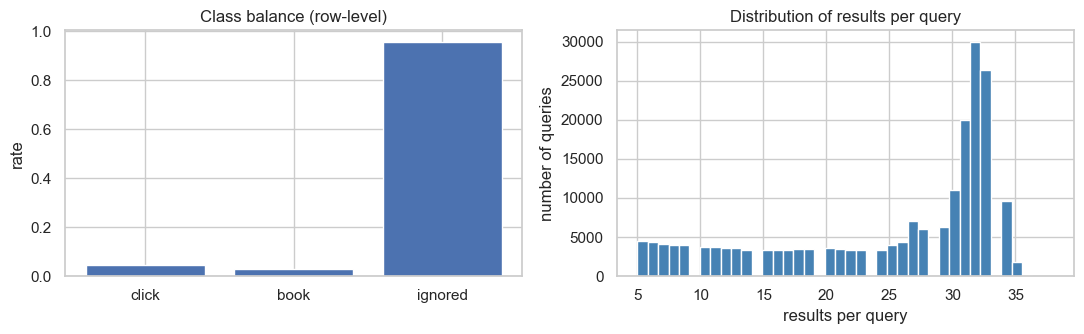

In [3]:
# Target distribution and class imbalance

click_rate = df['click_bool'].mean()
book_rate = df['booking_bool'].mean()
print(f"Click rate:   {click_rate:.4f}")
print(f"Booking rate: {book_rate:.4f}")

# Positives per query
clicks_per_q = df.groupby('srch_id')['click_bool'].sum()
books_per_q  = df.groupby('srch_id')['booking_bool'].sum()
print("\nClicks per query:")
print(clicks_per_q.value_counts().sort_index().head(10))
print("\nBookings per query:")
print(books_per_q.value_counts().sort_index().head(10))

# Results per query
results_per_q = df.groupby('srch_id').size()
print(f"\nResults per query: mean={results_per_q.mean():.1f}, median={results_per_q.median()}, min={results_per_q.min()}, max={results_per_q.max()}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(['click', 'book', 'ignored'],
            [click_rate, book_rate, 1 - click_rate])
axes[0].set_ylabel("rate")
axes[0].set_title("Class balance (row-level)")
axes[1].hist(results_per_q, bins=40, color="steelblue")
axes[1].set_xlabel("results per query")
axes[1].set_ylabel("number of queries")
axes[1].set_title("Distribution of results per query")
savefig("target_distribution")
plt.show()

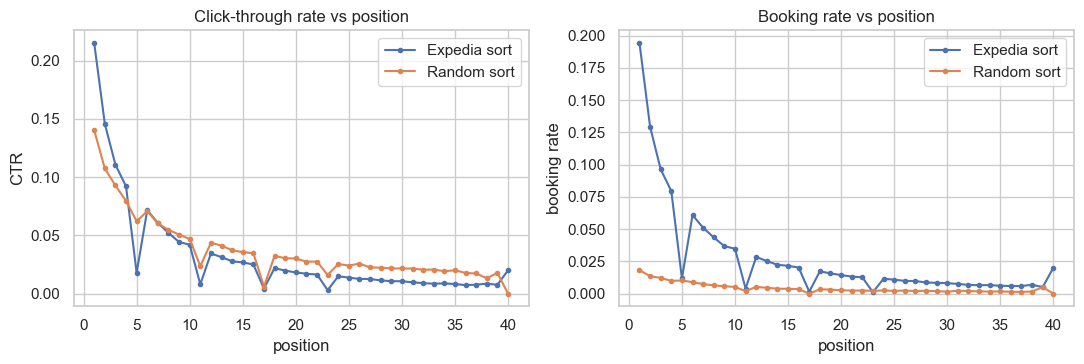

Share of rows with random_bool=1: 0.2959


In [4]:
# Position bias: CTR and booking rate vs position, split by random_bool

pos_stats = (df.groupby(['random_bool', 'position'])
               .agg(ctr=('click_bool', 'mean'),
                    book=('booking_bool', 'mean'),
                    n=('click_bool', 'size'))
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for rb, label in [(0, "Expedia sort"), (1, "Random sort")]:
    s = pos_stats[pos_stats['random_bool'] == rb]
    axes[0].plot(s['position'], s['ctr'], marker='o', markersize=3, label=label)
    axes[1].plot(s['position'], s['book'], marker='o', markersize=3, label=label)
axes[0].set_xlabel("position"); axes[0].set_ylabel("CTR")
axes[0].set_title("Click-through rate vs position"); axes[0].legend()
axes[1].set_xlabel("position"); axes[1].set_ylabel("booking rate")
axes[1].set_title("Booking rate vs position"); axes[1].legend()
savefig("position_bias")
plt.show()

print("Share of rows with random_bool=1:", df['random_bool'].mean().round(4))

price_usd describe:
count    4.958347e+06
mean     2.542096e+02
std      1.600124e+04
min      0.000000e+00
1%       3.400000e+01
25%      8.500000e+01
50%      1.220000e+02
75%      1.849600e+02
99%      5.990000e+02
max      1.972633e+07
Name: price_usd, dtype: float64
Rows with price_usd <= 0: 31
Rows with price_usd > 5000: 2871


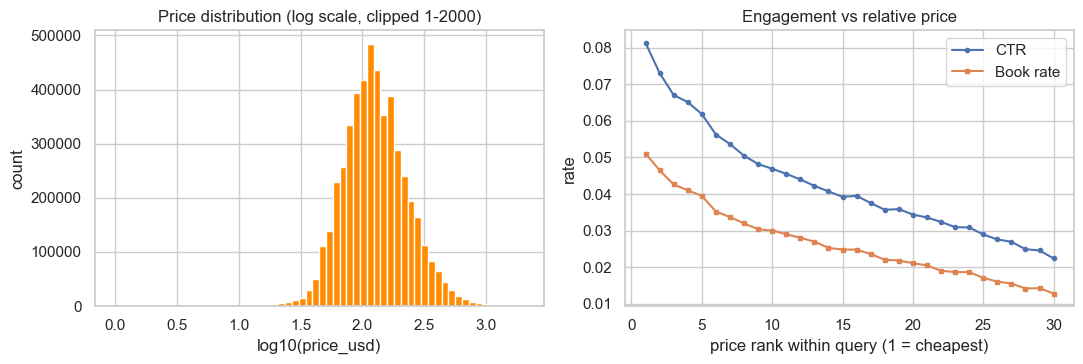

In [5]:
# Price patterns: distribution, outliers, relative price within query

print("price_usd describe:")
print(df['price_usd'].describe(percentiles=[.01, .25, .5, .75, .99]))
print("Rows with price_usd <= 0:", (df['price_usd'] <= 0).sum())
print("Rows with price_usd > 5000:", (df['price_usd'] > 5000).sum())

# Relative price within query (lower rank = cheaper)
df['price_rank_in_query'] = df.groupby('srch_id')['price_usd'].rank(method='min')
ctr_by_rank = (df.groupby('price_rank_in_query')
                 .agg(ctr=('click_bool', 'mean'),
                      book=('booking_bool', 'mean'),
                      n=('click_bool', 'size'))
                 .reset_index())
ctr_by_rank = ctr_by_rank[ctr_by_rank['price_rank_in_query'] <= 30]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
clipped = df.loc[df['price_usd'].between(1, 2000), 'price_usd']
axes[0].hist(np.log10(clipped), bins=60, color="darkorange")
axes[0].set_xlabel("log10(price_usd)"); axes[0].set_ylabel("count")
axes[0].set_title("Price distribution (log scale, clipped 1-2000)")

axes[1].plot(ctr_by_rank['price_rank_in_query'], ctr_by_rank['ctr'], marker='o', markersize=3, label="CTR")
axes[1].plot(ctr_by_rank['price_rank_in_query'], ctr_by_rank['book'], marker='s', markersize=3, label="Book rate")
axes[1].set_xlabel("price rank within query (1 = cheapest)")
axes[1].set_ylabel("rate")
axes[1].set_title("Engagement vs relative price")
axes[1].legend()
savefig("price_patterns")
plt.show()

CTR / book by star rating:
    prop_starrating       ctr      book        n
0                0  0.029032  0.016506   169572
1                1  0.027896  0.013314    17350
2                2  0.033937  0.021844   895894
3                3  0.043867  0.028090  1947598
4                4  0.053829  0.033223  1521448
5                5  0.046090  0.025915   406485

CTR / book by brand (1=chain):
    prop_brand_bool       ctr      book        n
0                0  0.044513  0.025741  1811287
1                1  0.044884  0.029159  3147060

CTR / book by promotion flag:
    promotion_flag       ctr      book        n
0               0  0.040473  0.024797  3889229
1               1  0.060301  0.039235  1069118


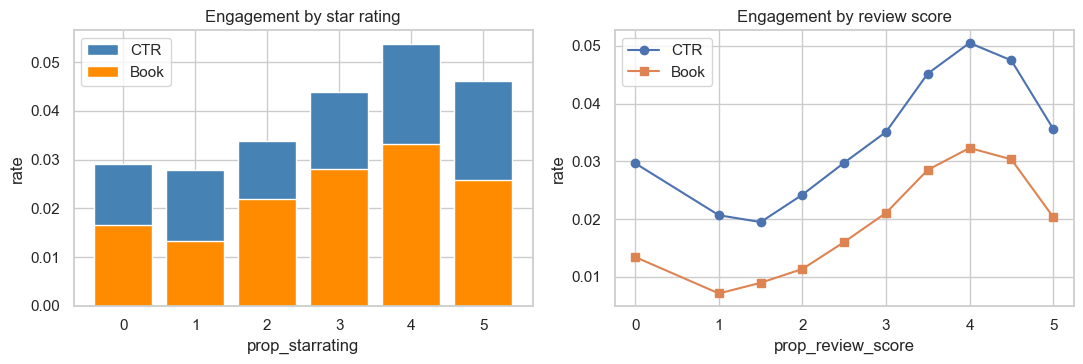

In [6]:
# Property quality: stars, review score, brand, promotion

def rates_by(col):
    g = df.groupby(col).agg(ctr=('click_bool', 'mean'),
                            book=('booking_bool', 'mean'),
                            n=('click_bool', 'size')).reset_index()
    return g

stars = rates_by('prop_starrating')
reviews = rates_by('prop_review_score')
brand = rates_by('prop_brand_bool')
promo = rates_by('promotion_flag')

print("CTR / book by star rating:\n", stars)
print("\nCTR / book by brand (1=chain):\n", brand)
print("\nCTR / book by promotion flag:\n", promo)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(stars['prop_starrating'], stars['ctr'], color="steelblue", label="CTR")
axes[0].bar(stars['prop_starrating'], stars['book'], color="darkorange", label="Book")
axes[0].set_xlabel("prop_starrating"); axes[0].set_ylabel("rate")
axes[0].set_title("Engagement by star rating"); axes[0].legend()

axes[1].plot(reviews['prop_review_score'], reviews['ctr'], marker='o', label="CTR")
axes[1].plot(reviews['prop_review_score'], reviews['book'], marker='s', label="Book")
axes[1].set_xlabel("prop_review_score"); axes[1].set_ylabel("rate")
axes[1].set_title("Engagement by review score"); axes[1].legend()
savefig("property_quality")
plt.show()

Columns with missing values (% missing):
comp1_rate_percent_diff      98.10
comp6_rate_percent_diff      98.06
comp1_rate                   97.58
comp1_inv                    97.39
comp4_rate_percent_diff      97.36
gross_bookings_usd           97.21
comp7_rate_percent_diff      97.21
comp6_rate                   95.16
visitor_hist_starrating      94.92
visitor_hist_adr_usd         94.90
comp6_inv                    94.74
comp4_rate                   93.80
comp7_rate                   93.64
srch_query_affinity_score    93.60
comp4_inv                    93.07
comp7_inv                    92.81
comp3_rate_percent_diff      90.46
comp2_rate_percent_diff      88.78
comp8_rate_percent_diff      87.60
comp5_rate_percent_diff      83.04
comp3_rate                   69.06
comp3_inv                    66.70
comp8_rate                   61.34
comp8_inv                    59.92
comp2_rate                   59.17
comp2_inv                    57.04
comp5_rate                   55.18
comp5_inv     

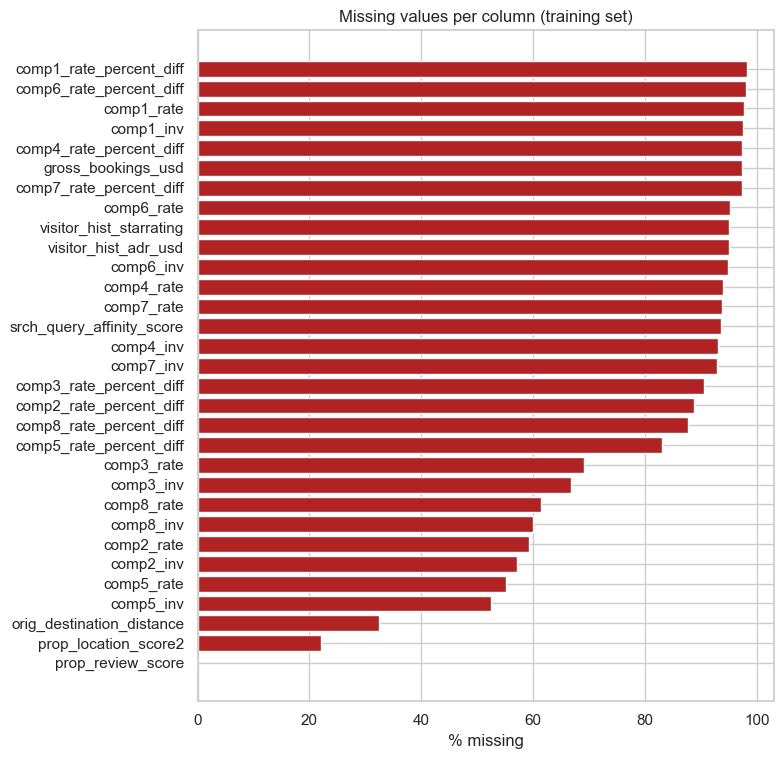

In [7]:
# Missingness: percentage of missing values per column

missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values (% missing):")
print((missing * 100).round(2).to_string())

fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(missing))))
ax.barh(missing.index[::-1], (missing.values[::-1]) * 100, color="firebrick")
ax.set_xlabel("% missing")
ax.set_title("Missing values per column (training set)")
savefig("missingness")
plt.show()

In [8]:

# DATA PREPARATION

# Goal: clean, impute and enrich the dataset before modeling.
# All transformations are applied to both training and test set
# through the helper function `prepare()` defined below, so that
# train and test stay aligned.


# Step 1: outlier handling on price_usd
# EDA showed values up to 1.97M and 31 zero-priced rows, both
# clearly erroneous. We clip the price to a realistic range
# (1, 5000) and store the clipped column as `price_clipped`.

PRICE_MIN, PRICE_MAX = 1.0, 5000.0

def clip_price(frame):
    frame['price_clipped'] = frame['price_usd'].clip(PRICE_MIN, PRICE_MAX)
    
    # The np.log1p() function is used instead of np.log() because it computes the natural logarithm of 1
    # plus the input value, which is more numerically stable when dealing with small values close to zero. 
    frame['log_price'] = np.log1p(frame['price_clipped'])
    return frame

df = clip_price(df)
print("price_clipped describe:")
print(df['price_clipped'].describe(percentiles=[.01, .5, .99]))

price_clipped describe:
count    4.958347e+06
mean     1.573224e+02
std      1.753686e+02
min      1.000000e+00
1%       3.400000e+01
50%      1.220000e+02
99%      5.990000e+02
max      5.000000e+03
Name: price_clipped, dtype: float64


In [9]:
# Step 2: missing value handling
# Strategy:
#   (a) for each column with missing values, add a binary flag
#       `<col>_missing` so the model can learn that "missing"
#       carries information.
#   (b) impute with the per-country first quartile, as done in
#       the reference paper (more robust to outliers than mean).
#   (c) the competitor *_rate_percent_diff columns are imputed
#       with 0 (no price difference) since "missing" usually
#       means the competitor is not present.

# Columns that benefit from per-country q1 imputation
NUM_IMPUTE = [
    'prop_review_score',
    'prop_location_score2',
    'orig_destination_distance',
    'srch_query_affinity_score',
    'visitor_hist_starrating',
    'visitor_hist_adr_usd',
]
COMP_DIFF_COLS = [f'comp{i}_rate_percent_diff' for i in range(1, 9)]

def add_missing_flags(frame, cols):
    for c in cols:
        frame[f'{c}_missing'] = frame[c].isna().astype('int8')
    return frame

def impute_per_country(frame, country_col='prop_country_id', cols=NUM_IMPUTE,
                       lookup=None):
    # lookup is a dict {col: Series indexed by country -> q1}.
    # If not provided, compute it from `frame` (training set).
    if lookup is None:
        lookup = {c: frame.groupby(country_col)[c].quantile(0.25) for c in cols}
    for c in cols:
        q1 = frame[country_col].map(lookup[c])
        global_q1 = frame[c].quantile(0.25)
        frame[c] = frame[c].fillna(q1).fillna(global_q1)
    return frame, lookup

df = add_missing_flags(df, NUM_IMPUTE + COMP_DIFF_COLS)
df, IMPUTE_LOOKUP = impute_per_country(df)
df[COMP_DIFF_COLS] = df[COMP_DIFF_COLS].fillna(0)

print("Remaining missing in imputed columns:")
print(df[NUM_IMPUTE].isna().sum().to_string())

Remaining missing in imputed columns:
prop_review_score            0
prop_location_score2         0
orig_destination_distance    0
srch_query_affinity_score    0
visitor_hist_starrating      0
visitor_hist_adr_usd         0


In [10]:
# Step 3: feature engineering
# We build three families of features:
#   (a) per-query relative features (rank and z-score within srch_id)
#       so that each property is described relative to its peers
#       in the same search.
#   (b) composite features inspired by the reference paper.
#   (c) competitor aggregates.

def add_engineered_features(frame):
    g = frame.groupby('srch_id')

    # (a) relative features within each query
    frame['price_rank_in_query'] = g['price_clipped'].rank(method='min')
    for col in ['price_clipped', 'prop_starrating', 'prop_review_score',
                'prop_location_score2']:
        mean = g[col].transform('mean')
        std  = g[col].transform('std').replace(0, 1).fillna(1)
        frame[f'{col}_z'] = (frame[col] - mean) / std

    # (b) composite features
    frame['price_per_night']    = frame['price_clipped'] / frame['srch_length_of_stay'].clip(lower=1)
    frame['price_per_person']   = frame['price_clipped'] / frame['srch_adults_count'].clip(lower=1)
    frame['count_window']       = frame['srch_room_count'] * (frame['srch_booking_window'] + 1)
    frame['price_diff_history'] = frame['price_clipped'] - frame['visitor_hist_adr_usd']
    frame['star_diff_history']  = frame['prop_starrating'] - frame['visitor_hist_starrating']
    frame['hist_price_delta']   = frame['log_price'] - frame['prop_log_historical_price']

    # (c) competitor aggregates
    rate_cols = [f'comp{i}_rate' for i in range(1, 9)]
    frame['n_comp_expedia_cheaper'] = (frame[rate_cols] == 1).sum(axis=1).astype('int8')
    frame['n_comp_expedia_pricier'] = (frame[rate_cols] == -1).sum(axis=1).astype('int8')
    frame['n_comp_available']       = frame[rate_cols].notna().sum(axis=1).astype('int8')

    # (d) simple flags
    frame['domestic']    = (frame['visitor_location_country_id'] ==
                            frame['prop_country_id']).astype('int8')
    frame['has_history'] = frame['visitor_hist_starrating'].notna().astype('int8')

    return frame

df = add_engineered_features(df)
print("New feature sample:")
print(df[['price_rank_in_query', 'price_clipped_z', 'price_per_night',
          'count_window', 'n_comp_expedia_cheaper', 'domestic']].head())

New feature sample:
   price_rank_in_query  price_clipped_z  price_per_night  count_window  \
0                  5.0        -0.611787           104.77             1   
1                 19.0         0.072867           170.74             1   
2                 20.0         0.166894           179.80             1   
3                 28.0         4.556587           602.77             1   
4                 16.0        -0.209007           143.58             1   

   n_comp_expedia_cheaper  domestic  
0                       0         0  
1                       0         0  
2                       0         0  
3                       0         0  
4                       0         0  


In [11]:
# Step 4: relevance label and train/validation split
# The competition is a learning-to-rank problem evaluated with
# NDCG@5. Following the standard convention for this dataset,
# we build a graded relevance label:
#     5 if the property was booked
#     1 if the property was clicked but not booked
#     0 if the property was ignored
# The split is done at query level (srch_id) to avoid leakage
# between train and validation.

from sklearn.model_selection import GroupShuffleSplit

df['relevance'] = (df['booking_bool'] * 5 +
                   df['click_bool'] * (1 - df['booking_bool']) * 1).astype('int8')

print("Relevance distribution:")
print(df['relevance'].value_counts(normalize=True).round(4))

splitter = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(splitter.split(df, groups=df['srch_id']))
df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)

print(f"\nTrain rows: {len(df_train):,} | queries: {df_train['srch_id'].nunique():,}")
print(f"Val   rows: {len(df_val):,} | queries: {df_val['srch_id'].nunique():,}")
print(f"\nVal click rate:   {df_val['click_bool'].mean():.4f}")
print(f"Val booking rate: {df_val['booking_bool'].mean():.4f}")

Relevance distribution:
relevance
0    0.9553
5    0.0279
1    0.0168
Name: proportion, dtype: float64

Train rows: 4,463,261 | queries: 179,815
Val   rows: 495,086 | queries: 19,980

Val click rate:   0.0448
Val booking rate: 0.0277


In [12]:
# Step 5: apply the same pipeline to the test set and persist
# the prepared datasets to disk. Using the imputation lookup
# computed on the training set guarantees no information leak.

def prepare(frame, impute_lookup):
    frame = clip_price(frame)
    frame = add_missing_flags(frame, NUM_IMPUTE + COMP_DIFF_COLS)
    frame, _ = impute_per_country(frame, lookup=impute_lookup)
    frame[COMP_DIFF_COLS] = frame[COMP_DIFF_COLS].fillna(0)
    frame = add_engineered_features(frame)
    return frame

df_test = pd.read_csv("data/test_set_VU_DM.csv")
df_test = prepare(df_test, IMPUTE_LOOKUP)

os.makedirs("processed", exist_ok=True)
df_train.to_parquet("processed/train.parquet", index=False)
df_val.to_parquet("processed/val.parquet", index=False)
df_test.to_parquet("processed/test.parquet", index=False)

print("Saved:")
for name in ["train.parquet", "val.parquet", "test.parquet"]:
    path = os.path.join("processed", name)
    print(f"  {path}  ({os.path.getsize(path) / 1e6:.1f} MB)")
print(f"\nFinal feature count: {df_test.shape[1]}")

Saved:
  processed/train.parquet  (284.1 MB)
  processed/val.parquet  (32.3 MB)
  processed/test.parquet  (310.2 MB)

Final feature count: 82


In [13]:

# MODELING AND EVALUATION

# Setup: load the prepared datasets, define the feature list
# and a NDCG@5 evaluator that we will reuse for every model.

train = pd.read_parquet("processed/train.parquet")
val   = pd.read_parquet("processed/val.parquet")
test  = pd.read_parquet("processed/test.parquet")

# Sort by srch_id so groupby and ranker `group=` arrays line up.
for d in (train, val, test):
    d.sort_values('srch_id', kind='mergesort', inplace=True)
    d.reset_index(drop=True, inplace=True)

# Drop targets, IDs and leakage columns from the feature list.
DROP = {
    'srch_id', 'prop_id', 'date_time',
    'click_bool', 'booking_bool', 'gross_bookings_usd',
    'position', 'relevance',
}
FEATURES = [c for c in train.columns
            if c not in DROP
            and pd.api.types.is_numeric_dtype(train[c])]
print(f"Number of features: {len(FEATURES)}")


def ndcg_at_5(scores, relevance, srch_ids):
    """Mean NDCG@5 across queries."""
    df_eval = pd.DataFrame({'s': scores, 'r': relevance, 'q': srch_ids})
    discounts = 1.0 / np.log2(np.arange(2, 7))   # positions 1..5

    def per_query(g):
        top   = g.sort_values('s', ascending=False)['r'].values[:5]
        ideal = np.sort(g['r'].values)[::-1][:5]
        dcg   = np.sum(top   * discounts[:len(top)])
        idcg  = np.sum(ideal * discounts[:len(ideal)])
        return dcg / idcg if idcg > 0 else 0.0

    return df_eval.groupby('q', sort=False)[['s', 'r']].apply(per_query).mean()


print(f"Train: {len(train):,} rows | Val: {len(val):,} rows | Test: {len(test):,} rows")

Number of features: 79
Train: 4,463,261 rows | Val: 495,086 rows | Test: 4,959,183 rows


In [14]:
# Model 1: Logistic Regression (pointwise baseline)
# Predicts P(book | features) row by row. Class-balanced so the
# model does not collapse to the majority "not booked" class.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train = train[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values
X_val   = val  [FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values
X_test  = test [FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=200, n_jobs=-1)
lr.fit(X_train_s, train['booking_bool'].values)

lr_val  = lr.predict_proba(X_val_s)[:, 1]
lr_test = lr.predict_proba(X_test_s)[:, 1]

ndcg_lr = ndcg_at_5(lr_val, val['relevance'].values, val['srch_id'].values)
print(f"Logistic Regression - val NDCG@5: {ndcg_lr:.4f}")

Logistic Regression - val NDCG@5: 0.3466


In [ ]:
# Model 2: LightGBM with LambdaRank (learning-to-rank)
# Optimises NDCG directly through the LambdaRank objective.
# Group sizes per srch_id are passed via `group=`.

import lightgbm as lgb

train_groups = train.groupby('srch_id', sort=False).size().values
val_groups   = val  .groupby('srch_id', sort=False).size().values

ranker = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

ranker.fit(
    train[FEATURES], train['relevance'],
    group=train_groups,
    eval_set=[(val[FEATURES], val['relevance'])],
    eval_group=[val_groups],
    eval_at=[5],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

lgbm_val  = ranker.predict(val [FEATURES])
lgbm_test = ranker.predict(test[FEATURES])

ndcg_lgbm = ndcg_at_5(lgbm_val, val['relevance'].values, val['srch_id'].values)
print(f"LightGBM LambdaRank - val NDCG@5: {ndcg_lgbm:.4f}")
print(f"Best iteration: {ranker.best_iteration_}")

In [ ]:
# Model 3: Matrix Factorization with Truncated SVD
# This is the recommender-systems lecture model.
# We build an implicit-feedback matrix indexed by
# (srch_destination_id, prop_id) where each cell counts
# 2 * #bookings + 1 * #clicks observed in the training data.
# A truncated SVD then yields latent factors for destinations
# and properties; the score for a candidate is the dot product
# of the two vectors.

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

dest_ids = train['srch_destination_id'].astype('int64').values
prop_ids = train['prop_id'].astype('int64').values
weights  = (2 * train['booking_bool'] + train['click_bool']).astype('float32').values

dest_index = {d: i for i, d in enumerate(np.unique(dest_ids))}
prop_index = {p: i for i, p in enumerate(np.unique(prop_ids))}

rows = np.fromiter((dest_index[d] for d in dest_ids), dtype=np.int32, count=len(dest_ids))
cols = np.fromiter((prop_index[p] for p in prop_ids), dtype=np.int32, count=len(prop_ids))

R = csr_matrix((weights, (rows, cols)),
               shape=(len(dest_index), len(prop_index)))
# Sum duplicate (dest, prop) pairs.
R.sum_duplicates()

svd = TruncatedSVD(n_components=32, random_state=42)
U = svd.fit_transform(R)            # (n_dest, k)
V = svd.components_.T               # (n_prop, k)
print(f"SVD shapes: U={U.shape}, V={V.shape}, "
      f"explained variance ratio sum={svd.explained_variance_ratio_.sum():.3f}")


def svd_score(frame):
    d = frame['srch_destination_id'].map(dest_index).fillna(-1).astype(int).values
    p = frame['prop_id'].map(prop_index).fillna(-1).astype(int).values
    out = np.zeros(len(frame), dtype=np.float32)
    mask = (d >= 0) & (p >= 0)
    out[mask] = np.einsum('ij,ij->i', U[d[mask]], V[p[mask]])
    return out


svd_val  = svd_score(val)
svd_test = svd_score(test)

ndcg_svd = ndcg_at_5(svd_val, val['relevance'].values, val['srch_id'].values)
print(f"Matrix Factorization (SVD) - val NDCG@5: {ndcg_svd:.4f}")
print(f"Test rows with unseen (dest, prop): {(svd_test == 0).sum():,}")

SVD shapes: U=(17344, 32), V=(127737, 32), explained variance ratio sum=0.475


Matrix Factorization (SVD) - val NDCG@5: 0.2719
Test rows with unseen (dest, prop): 981,734


In [ ]:
# Ensemble: per-query z-score normalization + weighted sum
# Each model's score is normalised inside every srch_id, then
# the three normalised scores are blended with non-negative
# weights tuned by a small grid search on validation NDCG@5.

def per_query_zscore(scores, srch_ids):
    s = pd.Series(scores)
    g = s.groupby(srch_ids)
    return ((s - g.transform('mean')) /
            (g.transform('std').replace(0, 1).fillna(1))).values


z_lr_val   = per_query_zscore(lr_val,   val['srch_id'].values)
z_lgbm_val = per_query_zscore(lgbm_val, val['srch_id'].values)
z_svd_val  = per_query_zscore(svd_val,  val['srch_id'].values)

z_lr_test   = per_query_zscore(lr_test,   test['srch_id'].values)
z_lgbm_test = per_query_zscore(lgbm_test, test['srch_id'].values)
z_svd_test  = per_query_zscore(svd_test,  test['srch_id'].values)

# Grid search over weights summing to 1, step 0.1.
best = (None, -1.0)
for w_lr in np.arange(0, 1.01, 0.1):
    for w_lgbm in np.arange(0, 1.01 - w_lr, 0.1):
        w_svd = 1.0 - w_lr - w_lgbm
        if w_svd < -1e-9:
            continue
        blend = w_lr * z_lr_val + w_lgbm * z_lgbm_val + w_svd * z_svd_val
        score = ndcg_at_5(blend, val['relevance'].values, val['srch_id'].values)
        if score > best[1]:
            best = ((round(w_lr, 2), round(w_lgbm, 2), round(w_svd, 2)), score)

(w_lr, w_lgbm, w_svd), ndcg_ens = best
print(f"Best weights  -> LR: {w_lr}, LGBM: {w_lgbm}, SVD: {w_svd}")
print(f"Ensemble - val NDCG@5: {ndcg_ens:.4f}")

# Apply the same weights to the test predictions.
ensemble_test = w_lr * z_lr_test + w_lgbm * z_lgbm_test + w_svd * z_svd_test

print("\n=== Summary ===")
print(f"  Logistic Regression : {ndcg_lr:.4f}")
print(f"  LightGBM LambdaRank : {ndcg_lgbm:.4f}")
print(f"  SVD MF              : {ndcg_svd:.4f}")
print(f"  Ensemble            : {ndcg_ens:.4f}")

Best weights  -> LR: 0.0, LGBM: 0.8, SVD: 0.2
Ensemble - val NDCG@5: 0.3999

=== Summary ===
  Logistic Regression : 0.3466
  LightGBM LambdaRank : 0.3935
  SVD MF              : 0.2719
  Ensemble            : 0.3999


In [ ]:
# Submission: rank test rows within each srch_id by the
# ensemble score and write the Kaggle CSV.

submission = (test.assign(score=ensemble_test)
                  .sort_values(['srch_id', 'score'],
                               ascending=[True, False])
                  [['srch_id', 'prop_id']])

submission.to_csv("submission.csv", index=False)
print(f"submission.csv written: {len(submission):,} rows, "
      f"{submission['srch_id'].nunique():,} unique srch_id")
print(submission.head(10))

submission.csv written: 4,959,183 rows, 199,549 unique srch_id
    srch_id  prop_id
9         1    54937
23        1    99484
5         1    28181
12        1    61934
8         1    50162
4         1    24194
6         1    34263
13        1    63894
18        1    82231
20        1    90385


In [ ]:
# ============================================================
# DEPLOYMENT - ETHICAL AI
# Query-level provider-fairness reranking.
# Group variable: prop_brand_bool (0 = independent, 1 = chain).
# We measure under-exposure of independent hotels in the top-5
# of the ensemble ranking and apply a small score boost only
# where they are under-represented, without retraining the model.
# ============================================================

# Make the ensemble score available on the validation set
# (the submission cell only stored the test version).
ensemble_val = w_lr * z_lr_val + w_lgbm * z_lgbm_val + w_svd * z_svd_val


def discounted_exposure(rank_values, k=5):
    r = np.asarray(rank_values, dtype=float)
    return np.where(r <= k, 1.0 / np.log2(r + 1.0), 0.0)


def build_rank_df(frame, scores, brand_col='prop_brand_bool',
                  rel_col='relevance'):
    """One row per (srch_id, prop_id) with rank, top-5 flag
    and group indicators."""
    cols = ['srch_id', 'prop_id', brand_col]
    if rel_col in frame.columns:
        cols.append(rel_col)
    out = frame[cols].copy()
    out['base_score']     = np.asarray(scores, dtype=float)
    out['is_independent'] = (out[brand_col] == 0).astype('int8')
    out['is_chain']       = (out[brand_col] == 1).astype('int8')
    out['rank'] = (out.groupby('srch_id')['base_score']
                       .rank(method='first', ascending=False)
                       .astype(float))
    out['in_top5'] = (out['rank'] <= 5).astype('int8')
    return out


def fairness_metrics(rank_df, score_col, k=5):
    df = rank_df.copy()
    df['disc_exposure'] = discounted_exposure(df['rank'].values, k=k)

    candidate_share_ind = df['is_independent'].mean()
    topk = df[df['in_top5'] == 1]
    topk_share_ind = topk['is_independent'].mean()

    total_disc = topk['disc_exposure'].sum()
    disc_share_ind = (
        topk.loc[topk['is_independent'] == 1, 'disc_exposure'].sum() / total_disc
        if total_disc > 0 else np.nan
    )

    avg_rank_ind   = df.loc[df['is_independent'] == 1, 'rank'].mean()
    avg_rank_chain = df.loc[df['is_chain']       == 1, 'rank'].mean()

    ndcg5 = (ndcg_at_5(df[score_col].values,
                       df['relevance'].values,
                       df['srch_id'].values)
             if 'relevance' in df.columns else np.nan)

    return {
        'candidate_share_independent':        float(candidate_share_ind),
        'top5_share_independent':             float(topk_share_ind),
        'discounted_top5_share_independent':  float(disc_share_ind),
        'representation_gap_independent':     float(topk_share_ind - candidate_share_ind),
        'avg_rank_independent':               float(avg_rank_ind),
        'avg_rank_chain':                     float(avg_rank_chain),
        'ndcg5':                              float(ndcg5),
    }


val_rank = build_rank_df(val, ensemble_val)
baseline = fairness_metrics(val_rank, 'base_score', k=5)
print("=== Baseline fairness metrics (ensemble, validation) ===")
for kk, vv in baseline.items():
    print(f"  {kk}: {vv:.4f}")

=== Baseline fairness metrics (ensemble, validation) ===
  candidate_share_independent: 0.3674
  top5_share_independent: 0.3513
  discounted_top5_share_independent: 0.3519
  representation_gap_independent: -0.0162
  avg_rank_independent: 14.6877
  avg_rank_chain: 14.4704
  ndcg5: 0.3999


In [ ]:
# Mitigation: query-level adaptive reranking.
# For every query we compute the under-exposure of independent
# hotels in the base top-5,
#     g_q = max(0, candidate_share_q - top5_share_q),
# and add a boost alpha * g_q only to independent hotels.
# Queries with no under-exposure receive no boost.

def query_underexposure(rank_df, score_col='base_score', k=5):
    tmp = rank_df[['srch_id', 'is_independent', score_col]].copy()
    tmp['rank_tmp'] = (tmp.groupby('srch_id')[score_col]
                          .rank(method='first', ascending=False)
                          .astype(float))
    candidate_share = tmp.groupby('srch_id')['is_independent'].mean()
    topk_share = (tmp[tmp['rank_tmp'] <= k]
                  .groupby('srch_id')['is_independent']
                  .mean())
    topk_share = candidate_share.index.to_series().map(topk_share).fillna(0.0)
    return (candidate_share - topk_share).clip(lower=0.0)


def apply_fair_rerank(rank_df, alpha, query_gap, k=5):
    out = rank_df.copy()
    out['query_underexposure'] = (out['srch_id'].map(query_gap)
                                                .fillna(0.0).astype(float))
    out['fair_score'] = (out['base_score'] +
                         float(alpha) * out['query_underexposure'] *
                         out['is_independent'])
    out['rank'] = (out.groupby('srch_id')['fair_score']
                       .rank(method='first', ascending=False)
                       .astype(float))
    out['in_top5'] = (out['rank'] <= k).astype('int8')
    return out


val_query_gap = query_underexposure(val_rank, score_col='base_score', k=5)

# Grid search on alpha. Pick the value that minimises |rep_gap|
# while keeping the NDCG@5 drop within 0.005.
alpha_grid = np.round(np.arange(0.00, 1.01, 0.05), 2)
rows = []
for alpha in alpha_grid:
    reranked = apply_fair_rerank(val_rank, alpha, val_query_gap, k=5)
    m = fairness_metrics(reranked, 'fair_score', k=5)
    m['alpha']    = float(alpha)
    m['ndcg_drop'] = float(baseline['ndcg5'] - m['ndcg5'])
    m['abs_rep_gap'] = abs(m['representation_gap_independent'])
    rows.append(m)
grid = pd.DataFrame(rows)

feasible = grid[grid['ndcg_drop'] <= 0.005]
chosen = (feasible if len(feasible) else grid).sort_values(
    ['abs_rep_gap', 'ndcg_drop', 'alpha'],
    ascending=[True, True, True]
).iloc[0]

best_alpha = float(chosen['alpha'])
print(f"Chosen alpha: {best_alpha}")
print(grid.round(4).to_string(index=False))

Chosen alpha: 0.5
 candidate_share_independent  top5_share_independent  discounted_top5_share_independent  representation_gap_independent  avg_rank_independent  avg_rank_chain  ndcg5  alpha  ndcg_drop  abs_rep_gap
                      0.3674                  0.3513                             0.3519                         -0.0162               14.6877         14.4704 0.3999   0.00     0.0000       0.0162
                      0.3674                  0.3530                             0.3534                         -0.0145               14.6683         14.4817 0.3999   0.05     0.0001       0.0145
                      0.3674                  0.3547                             0.3548                         -0.0127               14.6489         14.4930 0.4001   0.10    -0.0001       0.0127
                      0.3674                  0.3563                             0.3562                         -0.0111               14.6291         14.5045 0.3999   0.15     0.0000       0.0111
  

In [ ]:
# Apply best alpha on the validation set and persist the
# before/after summary plus all the values used in the report.

val_rank_fair = apply_fair_rerank(val_rank, best_alpha, val_query_gap, k=5)
after = fairness_metrics(val_rank_fair, 'fair_score', k=5)

summary = pd.DataFrame([
    {'stage': 'before_mitigation', 'alpha': 0.0,           **baseline},
    {'stage': 'after_mitigation',  'alpha': best_alpha,    **after},
])

report_values = {
    'chosen_alpha':                              best_alpha,
    'baseline_ndcg5':                            baseline['ndcg5'],
    'mitigated_ndcg5':                           after['ndcg5'],
    'independent_candidate_share':               baseline['candidate_share_independent'],
    'independent_top5_share_before':             baseline['top5_share_independent'],
    'independent_top5_share_after':              after['top5_share_independent'],
    'independent_discounted_top5_share_before':  baseline['discounted_top5_share_independent'],
    'independent_discounted_top5_share_after':   after['discounted_top5_share_independent'],
    'representation_gap_before':                 baseline['representation_gap_independent'],
    'representation_gap_after':                  after['representation_gap_independent'],
    'avg_rank_independent_before':               baseline['avg_rank_independent'],
    'avg_rank_independent_after':                after['avg_rank_independent'],
    'avg_rank_chain_before':                     baseline['avg_rank_chain'],
    'avg_rank_chain_after':                      after['avg_rank_chain'],
    'mean_query_underexposure_before':           float(val_query_gap.mean()),
}

os.makedirs('outputs', exist_ok=True)
summary.to_csv('outputs/fairness_summary.csv', index=False)
grid.to_csv('outputs/fairness_alpha_grid.csv', index=False)
pd.DataFrame([report_values]).to_csv('outputs/fairness_report_values.csv', index=False)

print("=== Before vs After ===")
print(summary.round(4).to_string(index=False))
print("\n=== Report values ===")
for k, v in report_values.items():
    print(f"  {k} = {v:.4f}")

=== Before vs After ===
            stage  alpha  candidate_share_independent  top5_share_independent  discounted_top5_share_independent  representation_gap_independent  avg_rank_independent  avg_rank_chain  ndcg5
before_mitigation    0.0                       0.3674                  0.3513                             0.3519                         -0.0162               14.6877         14.4704 0.3999
 after_mitigation    0.5                       0.3674                  0.3670                             0.3661                         -0.0004               14.4895         14.5856 0.4000

=== Report values ===
  chosen_alpha = 0.5000
  baseline_ndcg5 = 0.3999
  mitigated_ndcg5 = 0.4000
  independent_candidate_share = 0.3674
  independent_top5_share_before = 0.3513
  independent_top5_share_after = 0.3670
  independent_discounted_top5_share_before = 0.3519
  independent_discounted_top5_share_after = 0.3661
  representation_gap_before = -0.0162
  representation_gap_after = -0.0004
  avg_ra

In [ ]:
# Apply the same reranking to the test set and write a
# fairness-aware submission alongside the original one.

test_rank      = build_rank_df(test, ensemble_test)
test_query_gap = query_underexposure(test_rank, score_col='base_score', k=5)
test_rank_fair = apply_fair_rerank(test_rank, best_alpha, test_query_gap, k=5)

submission_fair = (test_rank_fair[['srch_id', 'prop_id', 'fair_score']]
                   .sort_values(['srch_id', 'fair_score'],
                                ascending=[True, False],
                                kind='mergesort')
                   [['srch_id', 'prop_id']])

submission_fair.to_csv('outputs/submission_fair.csv', index=False)

print(f"submission_fair.csv written: {len(submission_fair):,} rows, "
      f"{submission_fair['srch_id'].nunique():,} unique searches")

submission_fair.csv written: 4,959,183 rows, 199,549 unique searches
